<h1>Near-Earth Object (NEO) analysis: identifying differences between hazardous and non-hazardous asteroids<h1>

<h3>The following Jupyter Notebook is dedicated to analyzing NEOs obtained from NASA's API, with approaches within the first two weeks of January 2025, with the goal of identifying factors that differentiate potentially hazardous and non-hazardous asteroids.</h3>

<h3>The dataset includes the following attributes for each asteroid:

*   **Estimated Diameter (Min & Max)** – The minimum and maximum estimated diameter (in kilometers) of the asteroid.
*   **Hazardous classification** – A boolean indicator of whether the asteroid is classified as hazardous.
*   **First & Last Observation Date** – The dates of the first and most recent recorded or predicted observations.
*   **First & Last Approach Distance to Earth** – The distance (in km) at which the asteroid first and last approached or will approach Earth.
*   **First & Last Approach Velocity** – The speed (in km/h) of the asteroid during its first and last approach.
*   **Orbiting Body** – The celestial body around which the asteroid orbits.
*   **Number of Approaches** –  The total recorded and predicted approaches of the asteroid to Earth.

<h3>Final conclusions on the differences of the two groups of asteroids are provided at the end of the document.
</h3>

In [2]:
#Import of required libraries
import requests
import psycopg2
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
#Connection to PostgreSQL database
try:
    conn = psycopg2.connect(
        host="xxx",
        dbname="postgres",
        user="postgres",
        password="xxxxx",
        port="5432"
    )
    print("Connected to the database.")
except Exception as e:
    print("Unable to connect to the database.")
    print(e)


Connected to the database.


In [ ]:
#SQL query to obtain all records and fields
query = """
SELECT * FROM asteroids;
"""
#Data load into a dataframe
df = pd.read_sql_query(query, conn)

<h1>1. Number of samples per group<h1>

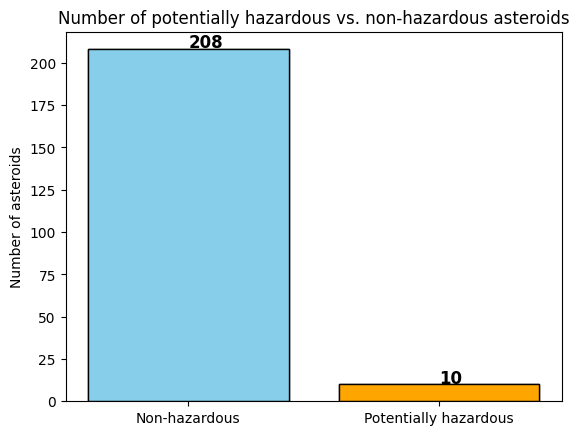

In [5]:
counts = df["is_potentially_hazardous"].value_counts()
plt.bar(counts.index.astype(str), counts.values, color=['skyblue', 'orange'], edgecolor='black')
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='left', va='center_baseline', fontsize=12, fontweight='bold')
plt.bar(counts.index.astype(str), counts.values, color=['skyblue', 'orange'], edgecolor='black')
plt.title("Number of potentially hazardous vs. non-hazardous asteroids")
plt.ylabel("Number of asteroids")
plt.xticks([0, 1], ["Non-hazardous", "Potentially hazardous"])
plt.show()

<h3>As the graph indicates, the data set is very unbalanced. There are 208 samples of the non-hazardous asteroids and 10 samples of the opposite group. For this reason, it is highly possible that the analysis is highly biased due to the under-representation of potentially hazardous asteroids.</h3>

<h1>2. Earth approach distance<h1>

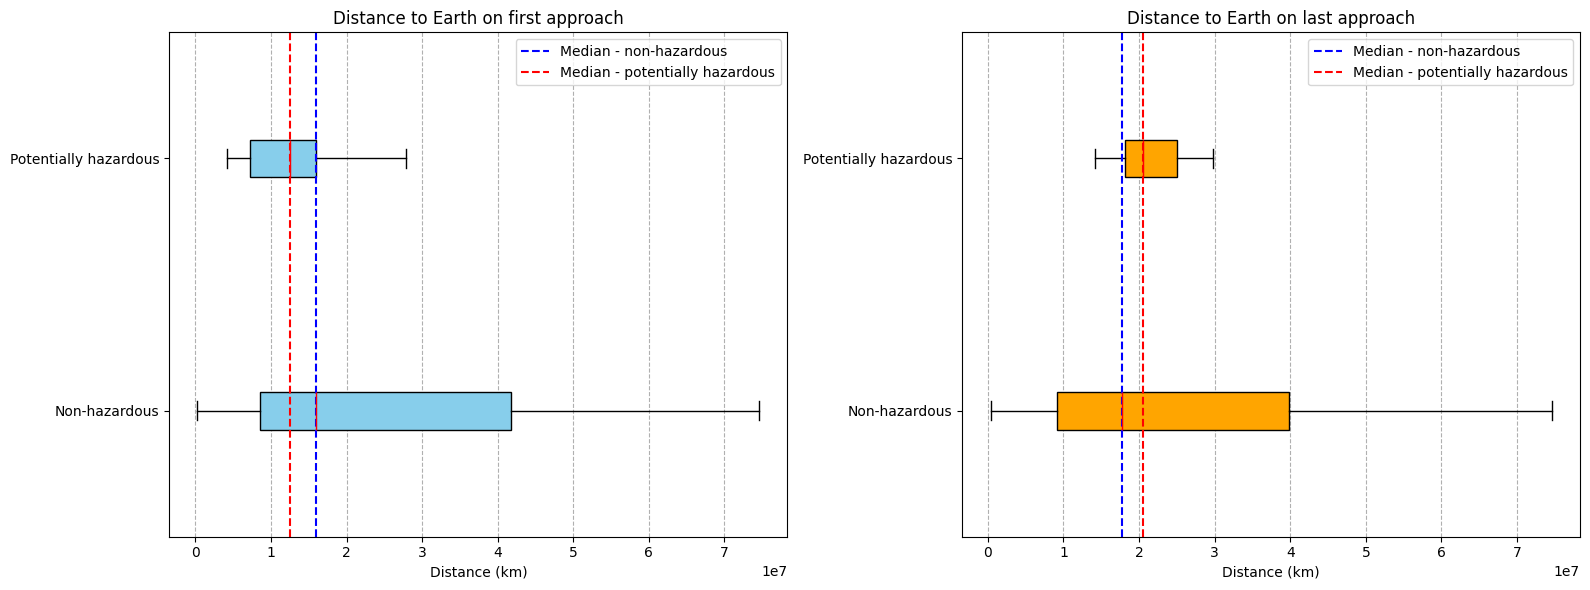

In [37]:
def remove_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series >= lower_bound) & (series <= upper_bound)]

approach_types = {"Distance to Earth on first approach": "first_approach_miss_distance", "Distance to Earth on last approach": "last_approach_miss_distance"}
box_colors = ["skyblue", "orange"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

for idx, (title, column) in enumerate(approach_types.items()):
    filtered_no_hazard = remove_outliers(df[df["is_potentially_hazardous"] == False][column])
    filtered_hazard = remove_outliers(df[df["is_potentially_hazardous"] == True][column])
    axes[idx].boxplot([filtered_no_hazard, filtered_hazard], vert=False, patch_artist=True, boxprops=dict(facecolor=box_colors[idx]), medianprops=dict(color="red"))
    axes[idx].axvline(filtered_no_hazard.median(), color='blue', linestyle='dashed', label="Median - non-hazardous")
    axes[idx].axvline(filtered_hazard.median(), color='red', linestyle='dashed', label="Median - potentially hazardous")
    axes[idx].grid(axis="x", linestyle="--")
    axes[idx].set_yticks([1, 2])
    axes[idx].set_yticklabels(["Non-hazardous", "Potentially hazardous"])
    axes[idx].set_title(title)
    axes[idx].set_xlabel("Distance (km)")
    axes[idx].legend()

plt.tight_layout()
plt.show()

<h3>As for the distance to Earth at first and last approach, no significant difference can be observed between the medians of each group. The non-potentially hazardous asteroids have a larger range of values than the opposite group. This does not seem to be a major determinant of the difference between the two groups.<h3>

<h1>3. Size comparison<h1>

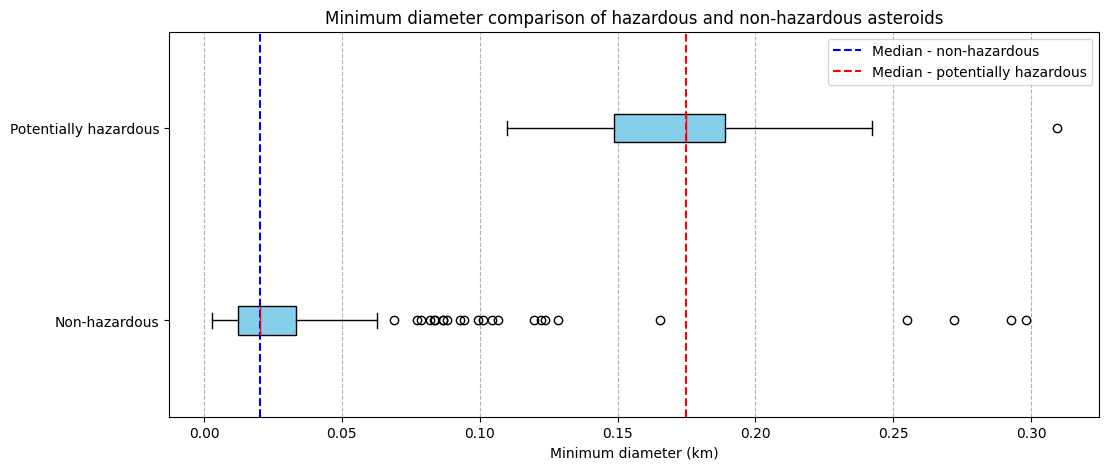

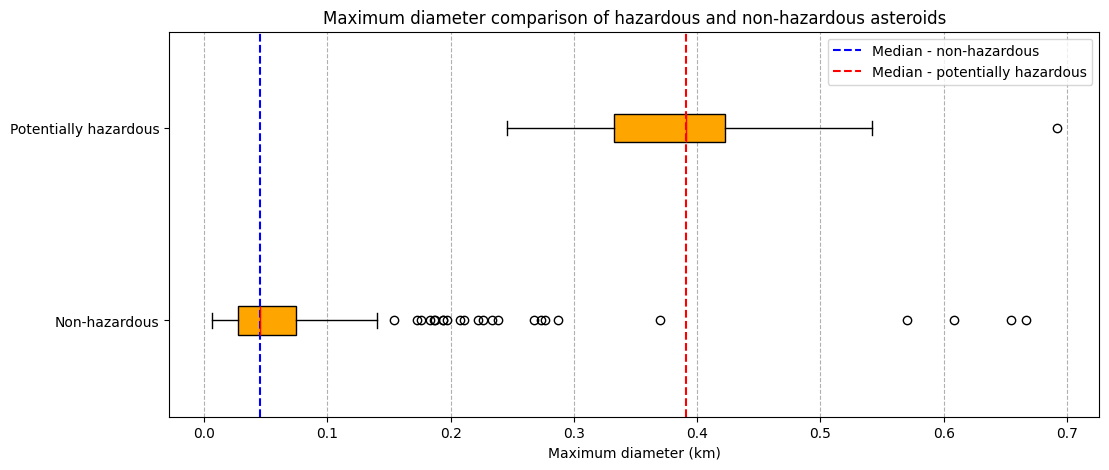

In [40]:
diameter_types = {"Minimum diameter": "estimated_diameter_min_km", "Maximum diameter": "estimated_diameter_max_km"}
box_colors = {"Minimum diameter": "skyblue", "Maximum diameter": "orange"}

for title, column in diameter_types.items():

    filtered_no_hazardous = df[df["is_potentially_hazardous"] == False][column]
    filtered_no_hazardous = filtered_no_hazardous[filtered_no_hazardous <= filtered_no_hazardous.quantile(0.95)]
    filtered_hazardous = df[df["is_potentially_hazardous"] == True][column]
    filtered_hazardous = filtered_hazardous[filtered_hazardous <= filtered_hazardous.quantile(0.95)]

    plt.figure(figsize=(12, 5))
    plt.boxplot([filtered_no_hazardous, filtered_hazardous], vert=False, patch_artist=True, boxprops=dict(facecolor=box_colors[title]), medianprops=dict(color="red"))
    plt.axvline(filtered_no_hazardous.median(), color='blue', linestyle='dashed', label="Median - non-hazardous")
    plt.axvline(filtered_hazardous.median(), color='red', linestyle='dashed', label="Median - potentially hazardous")
    plt.grid(axis="x", linestyle="--")
    plt.yticks([1, 2], ["Non-hazardous", "Potentially hazardous"])
    plt.title(f"{title} comparison of hazardous and non-hazardous asteroids")
    plt.xlabel(f"{title} (km)")
    plt.legend()
    plt.show()

<h3>In both the minimum and maximum diameter boxplots, there is a clear size difference between the two groups. The difference in medians is quite noticeable. Although there are a few outliers in the non-hazardous group, potentially hazardous asteroids tend to be larger in size.</h3>



<h1>4. Velocity of approach<h1>

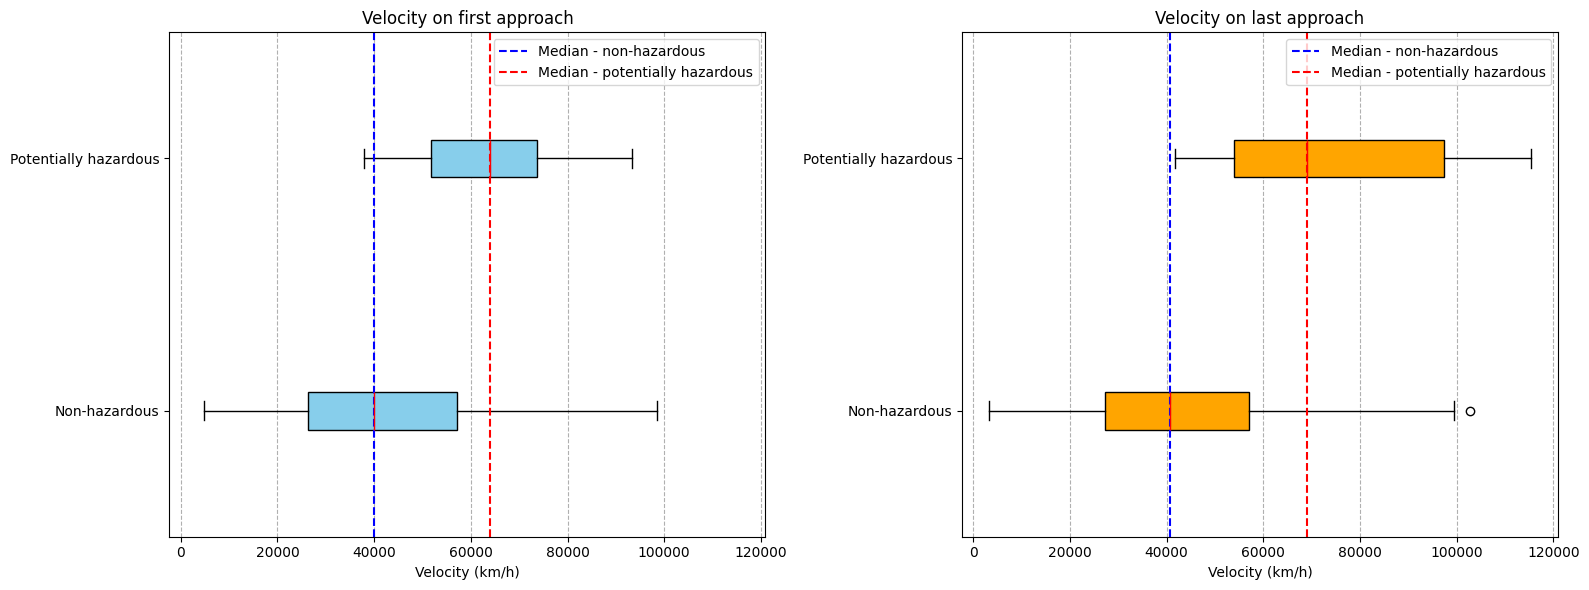

In [18]:
velocity_types = {"Velocity on first approach": "first_approach_kmh","Velocity on last approach": "last_approach_kmh"}

box_colors = ["skyblue", "orange"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

for idx, (title, column) in enumerate(velocity_types.items()):
    filtered_no_hazard = remove_outliers(df[df["is_potentially_hazardous"] == False][column])
    filtered_hazard = remove_outliers(df[df["is_potentially_hazardous"] == True][column])
    axes[idx].boxplot([filtered_no_hazard, filtered_hazard], vert=False, patch_artist=True, boxprops=dict(facecolor=box_colors[idx]), medianprops=dict(color="red"))
    axes[idx].axvline(filtered_no_hazard.median(), color='blue', linestyle='dashed', label="Median - non-hazardous")
    axes[idx].axvline(filtered_hazard.median(), color='red', linestyle='dashed', label="Median - potentially hazardous")
    axes[idx].grid(axis="x", linestyle="--")
    axes[idx].set_yticks([1, 2])
    axes[idx].set_yticklabels(["Non-hazardous", "Potentially hazardous"])
    axes[idx].set_title(title)
    axes[idx].set_xlabel("Velocity (km/h)")
    axes[idx].legend()

plt.tight_layout()
plt.show()

<h3>The variation between the medians of both the first and last approaches has a consistent value. Non-hazardous asteroids have a wide range of values, whereas hazardous asteroids tend to focus more on the higher velocities. The potentially hazardous asteroids tend to orbit with a higher velocity.</h3>

<h1>5. Velocity difference between first and last approach<h1>

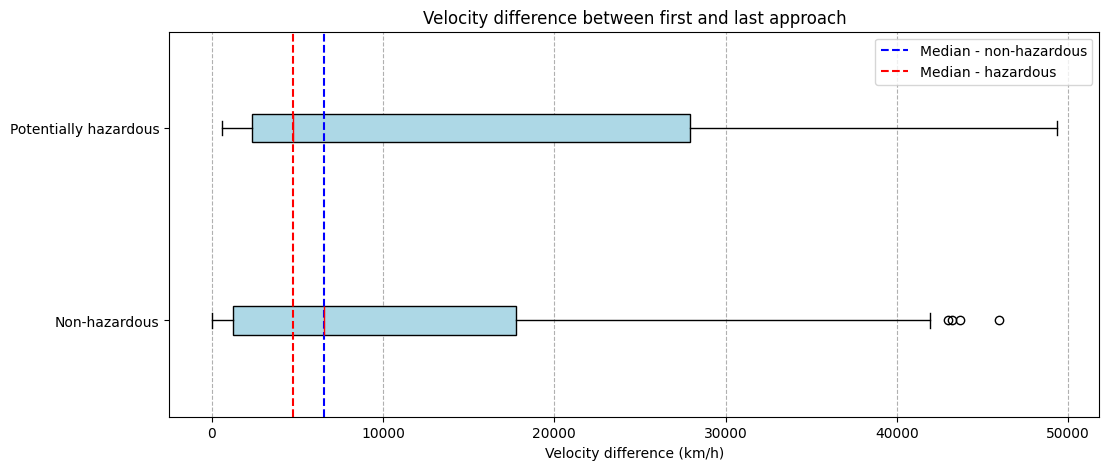

In [41]:
df["velocity_difference"] = abs(df["last_approach_kmh"] - df["first_approach_kmh"])
filtered_velocity_no_hazardous = remove_outliers(df[df["is_potentially_hazardous"] == False]["velocity_difference"])
filtered_velocity_hazardous = remove_outliers(df[df["is_potentially_hazardous"] == True]["velocity_difference"])

plt.figure(figsize=(12, 5))
plt.boxplot([filtered_velocity_no_hazardous, filtered_velocity_hazardous], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"), medianprops=dict(color="red"))
plt.axvline(filtered_velocity_no_hazardous.median(), color='blue', linestyle='dashed', label="Median - non-hazardous")
plt.axvline(filtered_velocity_hazardous.median(), color='red', linestyle='dashed', label="Median - hazardous")
plt.grid(axis="x", linestyle="--")
plt.yticks([1, 2], ["Non-hazardous", "Potentially hazardous"])
plt.title("Velocity difference between first and last approach")
plt.xlabel("Velocity difference (km/h)")
plt.legend()
plt.show()

<h3>Similarly to the values of the distance to Earth at first and last approach, there is no significant difference between the medians of each group.In this case, the potentially hazardous asteroids have a larger range of values than the opposite group.<h3>

<h1>6. Correlation between size and velocity</h1>

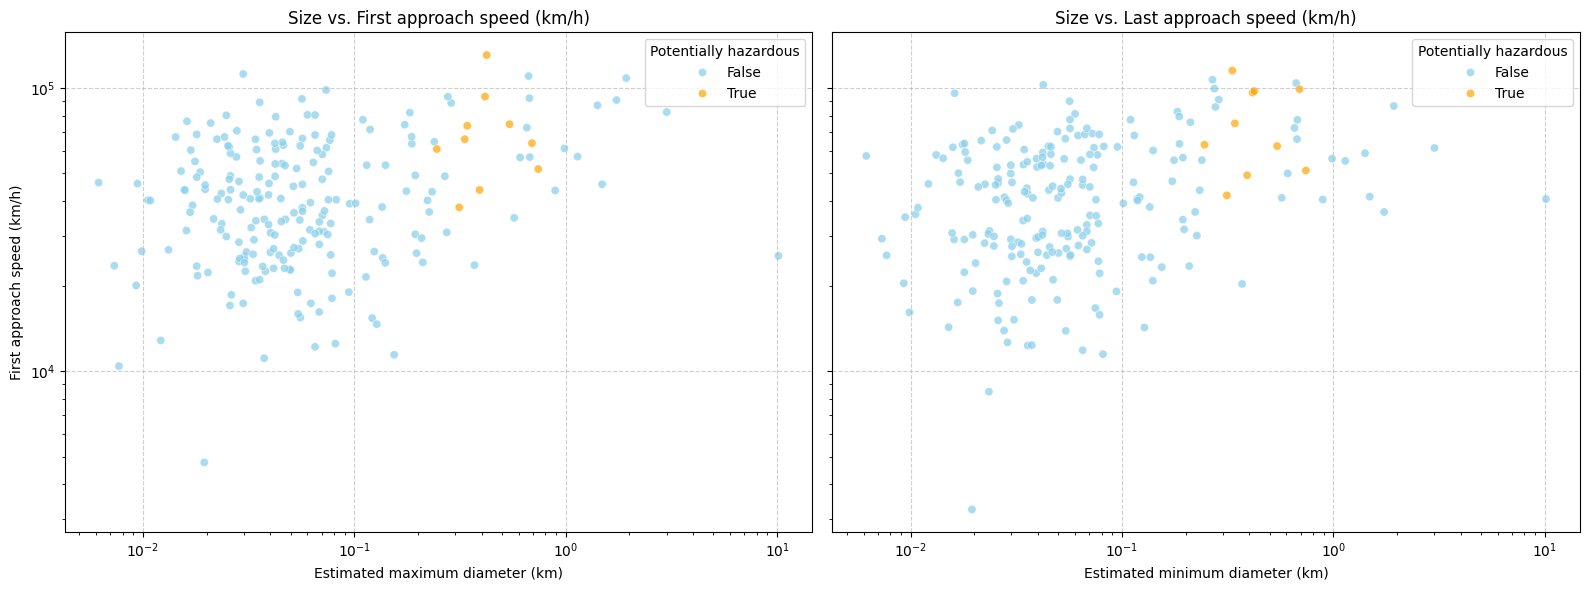

In [65]:
approach_types = {"First approach speed (km/h)": "first_approach_kmh", "Last approach speed (km/h)": "last_approach_kmh"}
x_Label = ["Estimated maximum diameter (km)", "Estimated minimum diameter (km)"]


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
scatter_settings = {"data": df,"x": "estimated_diameter_max_km","hue": "is_potentially_hazardous","palette": {True: "orange", False: "skyblue"},"alpha": 0.7}

for i, (title, column) in enumerate(approach_types.items()):
    sns.scatterplot(y=df[column], ax=axes[i], **scatter_settings)
    axes[i].set_xscale("log")
    axes[i].set_yscale("log")
    axes[i].set_title(f"Size vs. {title}")
    axes[i].set_ylabel(title)
    axes[i].set_xlabel(x_Label[i])
    axes[i].grid(True, linestyle="--", alpha=0.6)
    axes[i].legend(title="Potentially hazardous", fontsize=10)

plt.tight_layout()
plt.show()


<h3>These two scatterplots confirm the conclusions regarding the speed and size of asteroids. The graphs show two distinct clusters: non-hazardous asteroids tend to be smaller and have slightly slower velocities compared to the other group.</h3>


<h1>7. Approach frequency to an orbiting body<h1>




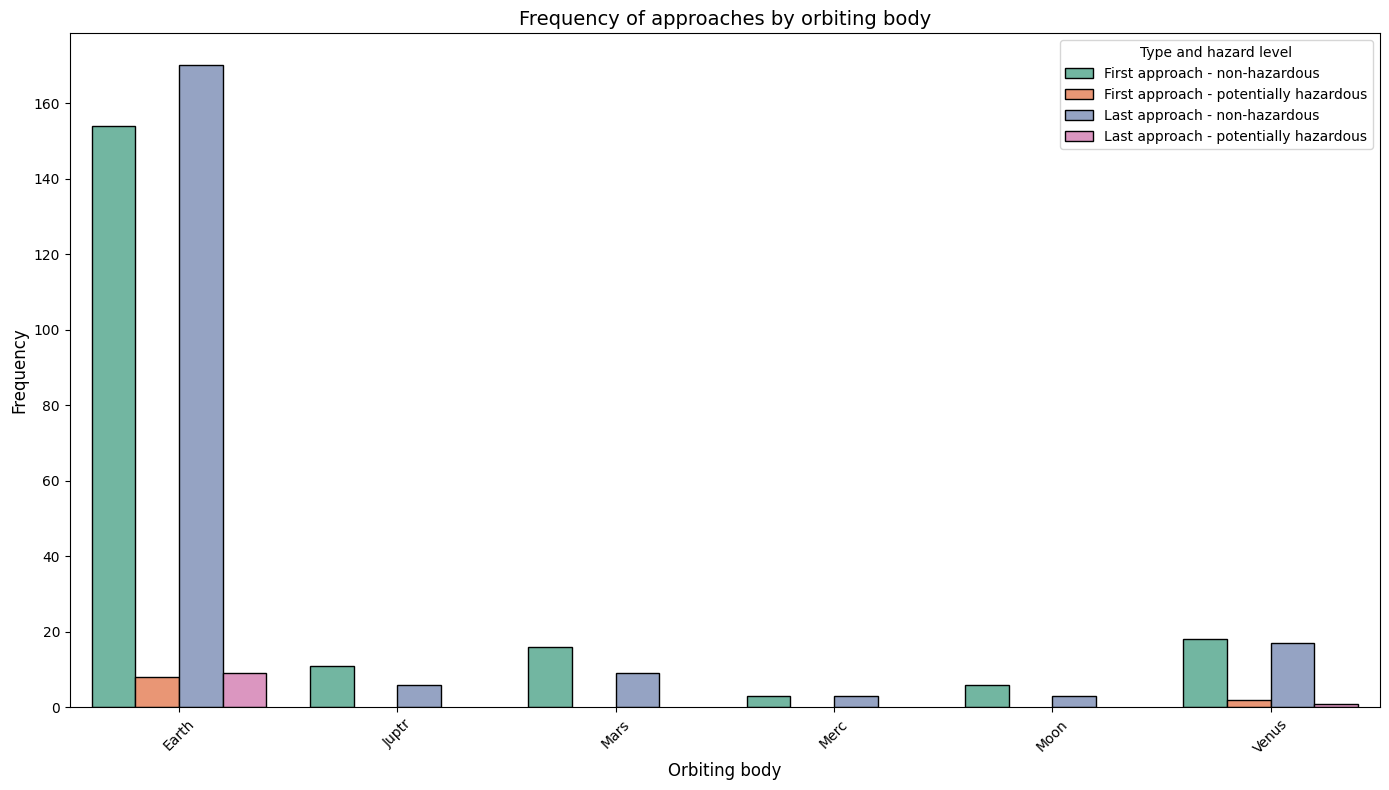

In [67]:
df["first_orbiting_body"] = df["first_orbiting_body"].fillna("Unknown")
df["last_orbiting_body"] = df["last_orbiting_body"].fillna("Unknown")

grouped = pd.concat([df.groupby(["first_orbiting_body", "is_potentially_hazardous"]).size().reset_index(name="count").assign(type="First approach"), df.groupby(["last_orbiting_body", "is_potentially_hazardous"]).size().reset_index(name="count").assign(type="Last approach")])
grouped["is_potentially_hazardous"] = grouped["is_potentially_hazardous"].replace({True: "potentially hazardous", False: "non-hazardous"})# Traducir los valores de peligrosidad
grouped["label"] = grouped["type"] + " - " + grouped["is_potentially_hazardous"]

plt.figure(figsize=(14, 8))
sns.barplot(data=grouped,x="first_orbiting_body", y="count", hue="label", errorbar=None, palette="Set2", edgecolor="black")
plt.title("Frequency of approaches by orbiting body", fontsize=14)
plt.xlabel("Orbiting body", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.legend(title="Type and hazard level", fontsize=10)
plt.tight_layout()
plt.show()

<h3>In general, both groups of asteroids have a clear tendency to approach the Earth and the planet Venus. Moreover, no potentially hazardous asteroid approaches to Jupiter, Mars, Mercury and the Moon are observed.<h3>

<h1>8. Number of approaches<h1>

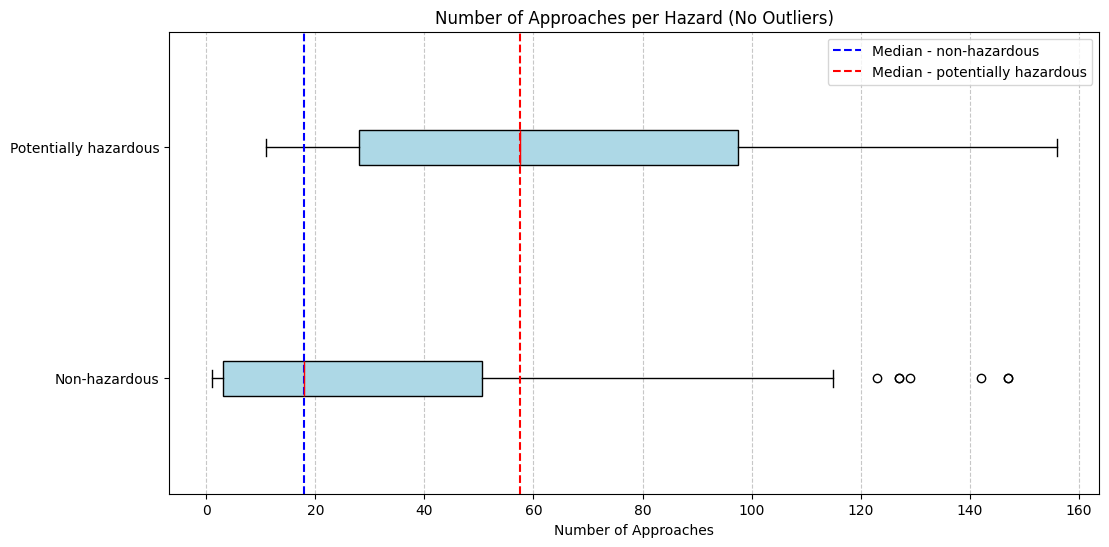

In [17]:
num_approaches_no_hazard = remove_outliers(df[df["is_potentially_hazardous"] == False]["num_approaches"])
num_approaches_hazard = remove_outliers(df[df["is_potentially_hazardous"] == True]["num_approaches"])

plt.figure(figsize=(12, 6))
plt.boxplot([num_approaches_no_hazard, num_approaches_hazard], vert=False, tick_labels=["Non-hazardous", "Potentially hazardous"], patch_artist=True, boxprops=dict(facecolor="lightblue"), medianprops=dict(color="red"))
plt.axvline(np.median(num_approaches_no_hazard), color='blue', linestyle='dashed', label="Median - non-hazardous")
plt.axvline(np.median(num_approaches_hazard), color='red', linestyle='dashed', label="Median - potentially hazardous")
plt.title("Number of Approaches per Hazard (No Outliers)")
plt.xlabel("Number of Approaches")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

<h3>The boxplot indicates that the non-hazardous asteroids have about 20 close approaches while the contarary group has about 60. Generally speaking, the hazardous asteroid group has more close approaches than the non-hazardous group.</h3>

<h1>9. Conclusions<h1>

<h3>In conclusion, clear differences can be observed between the two groups of asteroids.</h3>

<h3>Potentially hazardous asteroids tend to be larger and travel at higher velocities compared to non-hazardous ones. Additionally, these asteroids generally have a higher number of approaches. Regarding their orbits, hazardous asteroids rarely approach Jupiter, Mars, Mercury, or the Moon.</h3>